In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm

In [ ]:
torch.set_default_device('cuda')

The PDE we are solving reads
$$\alpha^2 y(\theta) = -\frac{\partial^2 y(\theta)}{\partial \theta},$$
and we are working on a circle, which implies that $\theta = \theta + 2\pi$. For the rest, we fix an arbitrary value for $\alpha$:

In [3]:
alpha = 1

To approximate a solution $\hat{y}(\theta)$, we construct a neural network. It takes as input $\theta$ and projects it to the trigonometric space $(\cos{\theta}, \sin{\theta})$.
By normalizing the output of the last layer by its L2 norm, we make sure that the output of the neural network has a norm of 1.

In [33]:
def l2_norm(func):
    # func is a torch.tensor of size [N,1], of the function evaluated at N points on [-pi,pi]
    return torch.linalg.vector_norm(func)* np.sqrt(2*np.pi/func.shape[0])
    
class PINN(nn.Module):
    def __init__(self, width=5):
        super().__init__()
        self.l1 = nn.Sequential(
            nn.Linear(2, width),
            nn.Tanh(),
            nn.Linear(width, width),
            nn.Tanh(),
            nn.Linear(width, width),
            nn.Tanh(),
            nn.Linear(width, 1)
        )
        
    def forward(self, theta):
        x1, x2 = torch.cos(alpha*theta), torch.sin(alpha*theta)
        x1x2 = torch.stack([x1, x2], axis=-1)
        outputs = self.l1(x1x2).squeeze()

        return outputs / l2_norm(outputs)

To train this neural network in a PINN fashion, we design a loss function which minimizes the PDE residuals. We call it the _PDE loss_. The trained neural network should be a function $\hat{y}$ that minimizes the mismatch between the left-hand side term and the right-hand side one, that is:
$$\operatorname{argmin}_{\hat{y}} (\alpha^2 \hat{y}(\theta) - \frac{\partial^2 \hat{y}(\theta)}{\partial \theta^2})^2
$$ 
for any $\theta$.

In [34]:
def loss_fn(model, theta):
    g = model(theta)
    dg_dtheta = torch.autograd.grad(g, [theta], grad_outputs=torch.ones_like(g), create_graph=True)[0]
    d2g_dtheta2 = torch.autograd.grad(dg_dtheta, [theta], grad_outputs=torch.ones_like(dg_dtheta), create_graph=True)[0]
    r_t = (-alpha**2 * g)
    l_t = d2g_dtheta2
    return (r_t-l_t)**2

Then, the training consist in the gradient descent of this loss function, over the weights of the neural network, for randomly sampled values of $\theta$ over $[-\pi, \pi]$.

In [38]:
n_steps = 1000
n_points = 100000
model = PINN()
def train(model, verbose=True):
    optimizer = optim.Adam(model.parameters(), lr=5e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=100)
    
    losses = []
    if verbose:
        pbar = tqdm(range(n_steps))
    else:
        pbar = range(n_steps)
    for i in pbar:
        optimizer.zero_grad()
        theta = (torch.rand(n_points, requires_grad=True)-0.5)*2*torch.pi
        loss = loss_fn(model, theta).mean()
        loss.backward()
        losses.append(loss.item())
        optimizer.step()
        scheduler.step(loss)
        if verbose:
            pbar.set_description(f"Loss: {np.mean(losses[-20:]).item():.5e}")
    return model, losses

In [45]:
model, losses = train(model)

  0%|          | 0/1000 [00:00<?, ?it/s]

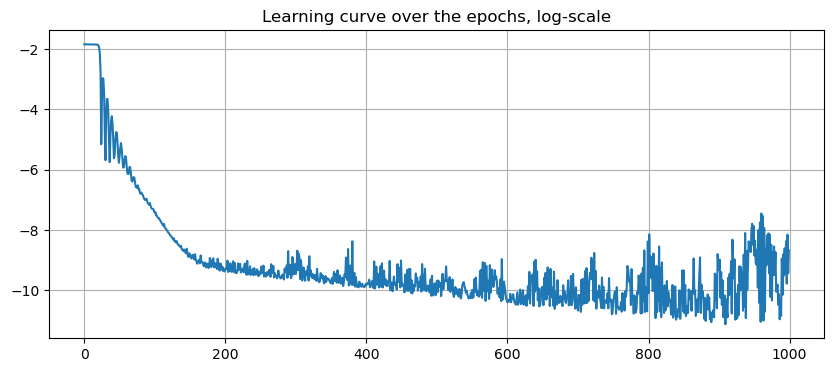

In [47]:
plt.figure(figsize=(10, 4))
plt.plot(np.log(losses))
plt.grid()
plt.title("Learning curve over the epochs, log-scale")
plt.show()

Now, we want to evaluate how close we are from a valid solution for the initial PDE. We know that the solutions have the form
$$y_{\theta_0} = \frac{1}{\sqrt{\pi}} \cos{\alpha (\theta+\theta_0)},$$
therefore, we can find the $\theta_0$ value that minimizes the mismatch between the correct solution and the neural network outputs:
Finding the best fit of the form $\frac{1}{\sqrt{\pi}} \cos\alpha(\theta+\theta_0)$ directly by solving
$$\operatorname{argmin}_{\theta_0} \left[\int_{-\pi}^{\pi} \left(\frac{1}{\sqrt{\pi}} \cos\alpha(\theta+\theta_0) - \hat{y}(\theta)\right)^2 d\theta\right]$$
$$\Rightarrow \qquad \theta_0 =\frac{1}{\alpha} \arctan{\left(-\frac{\sum_\theta \hat{y}(\theta)\sin(\alpha\theta)}{\sum_\theta \hat{y}(\theta)\cos(\alpha\theta)}\right)}$$
which yields

In [48]:
def get_theta0(model):
    thetas = torch.linspace(-np.pi,np.pi, n_points)
    y_hat = model(thetas)
    sin_sum = torch.sum(y_hat*torch.sin(thetas))
    cos_sum = torch.sum(y_hat*torch.cos(thetas))
    theta0_compute = torch.arctan2(-sin_sum,cos_sum)/alpha
    return theta0_compute
theta0_compute = get_theta0(model)
print(f"Optimal Theta: {theta0_compute:.5f}")

Optimal Theta: -2.87171


In [43]:
def sol(theta, theta0):
    return (1/(torch.pi**0.5))*torch.cos(alpha*(theta+theta0))

We can update the display function to show the PINN solution alongside the closest correct solution. We call _data loss_ the L2 norm between the PINN outputs and the closest correct solution. 

In [40]:
def display_solution_with_fit(model, theta0):
    theta = torch.linspace(-np.pi, np.pi, 500, requires_grad = True)
    g = model(theta).detach()
    max_g = 2*torch.max(torch.abs(g))
    best_g = sol(theta, theta0)
    max_best_g = 2*torch.max(torch.abs(best_g))
    
    fig, ax = plt.subplots(1, 2, figsize=(15, 7))
    ax[0].plot((torch.cos(theta)*(1+g/max_g)).detach().cpu().numpy(), (torch.sin(theta)*(1+g/max_g)).detach().cpu().numpy(), label='nn')
    ax[0].plot((torch.cos(theta)*(1+best_g/max_best_g)).detach().cpu().numpy(), (torch.sin(theta)*(1+best_g/max_best_g)).detach().cpu().numpy(), linestyle='dashed', label='best_fit')
    ax[0].plot(torch.cos(theta).detach().cpu().numpy(), torch.sin(theta).detach().cpu().numpy(), label='circle')
    ax[0].arrow(0,0, (torch.cos(-theta0)*.8).detach().cpu().numpy(), (torch.sin(-theta0)*0.8).detach().cpu().numpy(), color="red", head_width=.05)
    ax[0].legend()
    ax[0].grid()
    ax[0].set_aspect("equal")
    ax[1].plot(theta.detach().cpu().numpy(), g.detach().cpu().numpy(), label='nn')
    ax[1].plot(theta.detach().cpu().numpy(), best_g.detach().cpu().numpy(), linestyle='dashed', label='best_fit')
    ax[1].legend()
    ax[1].grid()
    plt.suptitle(f"L2 norm between y_theta0 and y_hat: {l2_norm(g-sol(theta,theta0)):.5e}")
    plt.show()

Optimal Theta: -2.87171


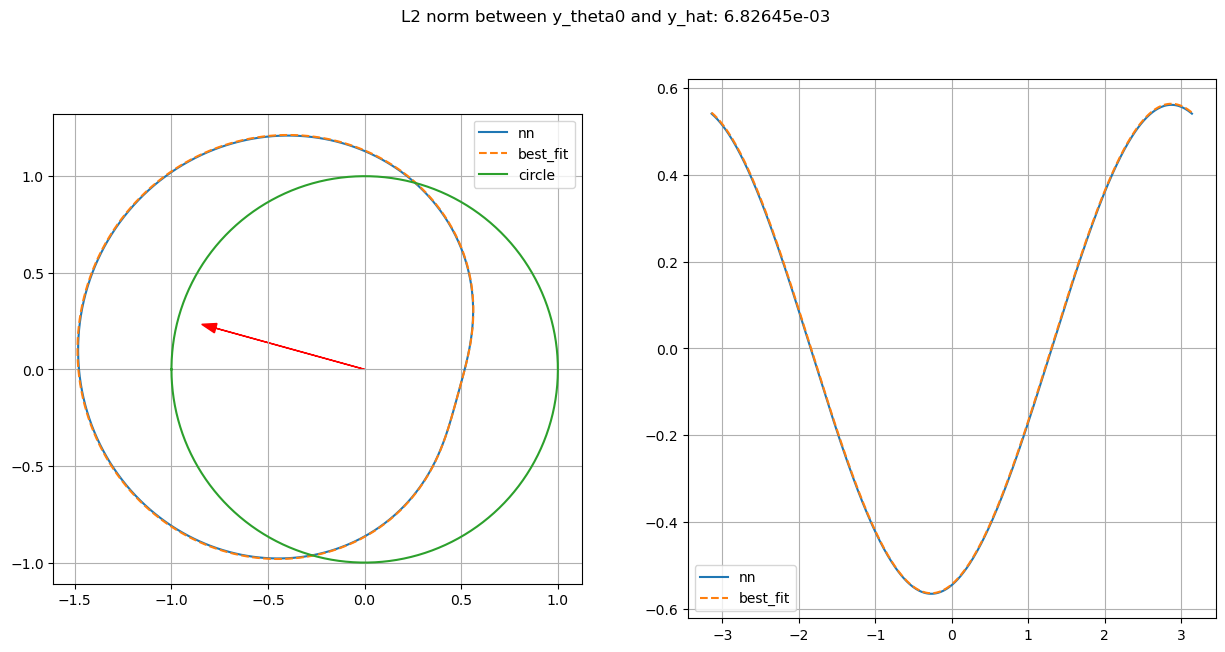

In [49]:
theta0 = get_theta0(model)
print(f"Optimal Theta: {theta0:.5f}")
display_solution_with_fit(model, theta0)

Now, how are the _data loss_ and the _PDE loss_ distributed for multiple values of $\theta_0$ ? Since we do not enforce $\theta_0$ in the training of the network, we have to estimate this distribution by Monte-Carlo.

In [14]:
errors = []
for _ in tqdm(range(300)):
    model, _ = train(PINN(), verbose=False)
    theta0 = get_theta0(model)
    theta = torch.linspace(-np.pi, np.pi, 1000, requires_grad = True)
    y_hat = model(theta)
    data_loss = l2_norm(y_hat-sol(theta, theta0)).item()
    pde_loss = loss_fn(model, theta).mean().item()
    if pde_loss<1e-1: # If the training has converged
        errors.append([theta0.item()%(2*np.pi), data_loss, pde_loss])

  0%|          | 0/300 [00:00<?, ?it/s]

We show how the _data loss_ and the _PDE loss_ are distributed according to $\theta_0$. We interpolate the error to have a smooth display.

In [ ]:
def plot_polar_metrics(data):
    angles = data[:, 0]
    m1 = np.log(data[:, 1])
    m2 = np.log(data[:, 2])
    angles_ext = np.r_[angles, angles[0] + 2*np.pi]
    m1_ext = np.r_[m1, m1[0]]
    m2_ext = np.r_[m2, m2[0]]
    theta = np.linspace(0, 2*np.pi, 2000)
    m1_i = np.interp(theta, angles_ext, m1_ext)
    m2_i = np.interp(theta, angles_ext, m2_ext)
    fig, axes = plt.subplots(1, 2, subplot_kw={'projection': 'polar'}, figsize=(13, 6))
    for ax, metric in zip(axes, [m1_i, m2_i]):
        norm = plt.Normalize(metric.min(), metric.max())
        cmap = plt.cm.hot
        colors = cmap(norm(metric))
        width = 2*np.pi / len(theta)
        r=ax.bar(theta, np.ones_like(theta),
               width=width,
               color=colors,
               edgecolor='none',
               align='edge')
        ax.set_ylim(0, 1)
        ax.set_yticks([])
        sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
        fig.colorbar(sm, ax=ax, pad=0.1, shrink=0.7)
        
    plt.suptitle("Data and PDE Losses")
    plt.tight_layout()
    plt.show()

In [ ]:
plot_polar_metrics(np.array(sorted(errors, key=lambda x: x[0]))

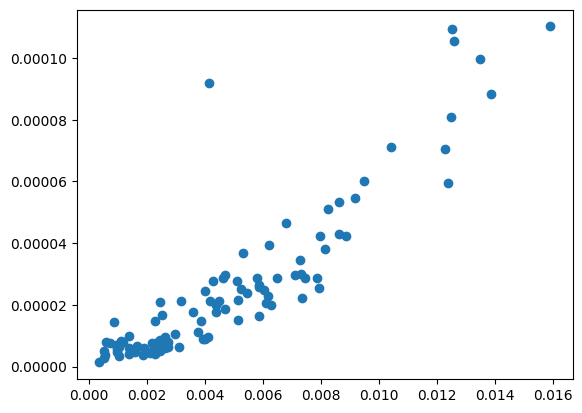

In [27]:
plt.scatter(np.log(errors[:, 1]),np.log(errors[:, 2]))

In [353]:
errors

array([[1.25954539e-01, 3.73760611e-03, 8.75341811e-06],
       [7.18028665e-01, 6.39575010e-04, 2.84605494e-06],
       [9.49679673e-01, 6.45437231e-03, 3.97331314e-05],
       [1.00571728e+00, 2.15164712e-03, 1.42336148e-05],
       [2.51357412e+00, 4.33538575e-04, 1.45912454e-05],
       [2.94663620e+00, 1.22733908e-02, 7.42689954e-05],
       [3.36748266e+00, 5.52962651e-04, 4.21861296e-06],
       [3.59929609e+00, 4.08211071e-03, 1.17776681e-05],
       [5.41507113e+00, 2.89879099e-04, 2.55011037e-06],
       [5.72216082e+00, 1.49754062e-03, 9.27580550e-06]])